In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
sns.set_theme(style="whitegrid")

os.makedirs("../charts", exist_ok=True)

conn = sqlite3.connect("../data/db/bluestock_mf.db")

nav_df = pd.read_csv("../data/processed/clean_nav.csv", parse_dates=['date'])
txn_df = pd.read_csv("../data/processed/clean_transactions.csv", parse_dates=['transaction_date'])
perf_df = pd.read_csv("../data/processed/clean_performance.csv")
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")
aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
cat_df = pd.read_csv("../data/raw/05_category_inflows.csv")
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")
holdings_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("✅ All libraries imported!")
print("✅ Database connected!")
print("✅ All datasets loaded!")
print(f"\nDatasets ready:")
print(f"  NAV History    : {nav_df.shape}")
print(f"  Transactions   : {txn_df.shape}")
print(f"  Performance    : {perf_df.shape}")
print(f"  Fund Master    : {fund_df.shape}")
print(f"  AUM Data       : {aum_df.shape}")
print(f"  SIP Inflows    : {sip_df.shape}")
print(f"  Category Flows : {cat_df.shape}")
print(f"  Folio Count    : {folio_df.shape}")
print(f"  Holdings       : {holdings_df.shape}")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported!
✅ Database connected!
✅ All datasets loaded!

Datasets ready:
  NAV History    : (64320, 3)
  Transactions   : (32778, 13)
  Performance    : (40, 19)
  Fund Master    : (40, 15)
  AUM Data       : (90, 5)
  SIP Inflows    : (48, 6)
  Category Flows : (144, 3)
  Folio Count    : (21, 6)
  Holdings       : (322, 8)


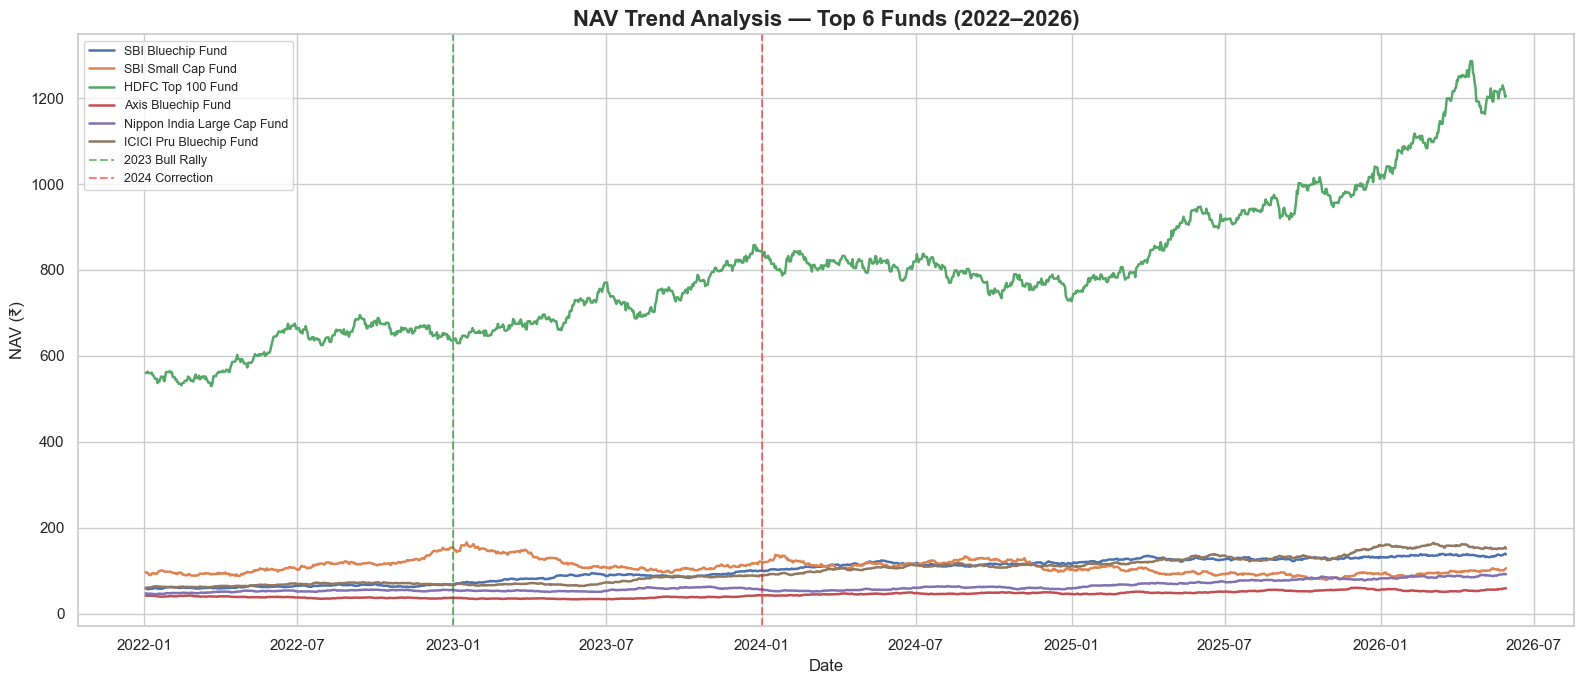

✅ Chart 1: NAV Trends saved!


In [2]:
# =====================
# TASK 1 - NAV TREND ANALYSIS
# =====================

# Fund master se merge karo naam ke liye
nav_merged = nav_df.merge(fund_df[['amfi_code', 'scheme_name', 'sub_category']],
                          on='amfi_code', how='left')

# Sirf 6 representative funds select karo
selected_funds = [
    'SBI Bluechip Fund - Direct Plan - Growth',
    'SBI Small Cap Fund - Direct Plan - Growth',
    'HDFC Top 100 Fund - Direct Plan - Growth',
    'Axis Bluechip Fund - Direct - Growth',
    'Nippon India Large Cap Fund - Direct - Growth',
    'ICICI Pru Bluechip Fund - Direct - Growth'
]

nav_selected = nav_merged[nav_merged['scheme_name'].isin(selected_funds)]

# Chart banao
fig, ax = plt.subplots(figsize=(16, 7))

for fund in selected_funds:
    data = nav_selected[nav_selected['scheme_name'] == fund]
    label = fund.replace(' - Direct Plan - Growth', '').replace(' - Direct - Growth', '')
    ax.plot(data['date'], data['nav'], linewidth=1.8, label=label)

# Milestones mark karo
ax.axvline(pd.Timestamp('2023-01-01'), color='green',
           linestyle='--', alpha=0.5, label='2023 Bull Rally')
ax.axvline(pd.Timestamp('2024-01-01'), color='red',
           linestyle='--', alpha=0.5, label='2024 Correction')

ax.set_title('NAV Trend Analysis — Top 6 Funds (2022–2026)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('NAV (₹)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../charts/01_nav_trends.png', dpi=150)
plt.show()
print("✅ Chart 1: NAV Trends saved!")

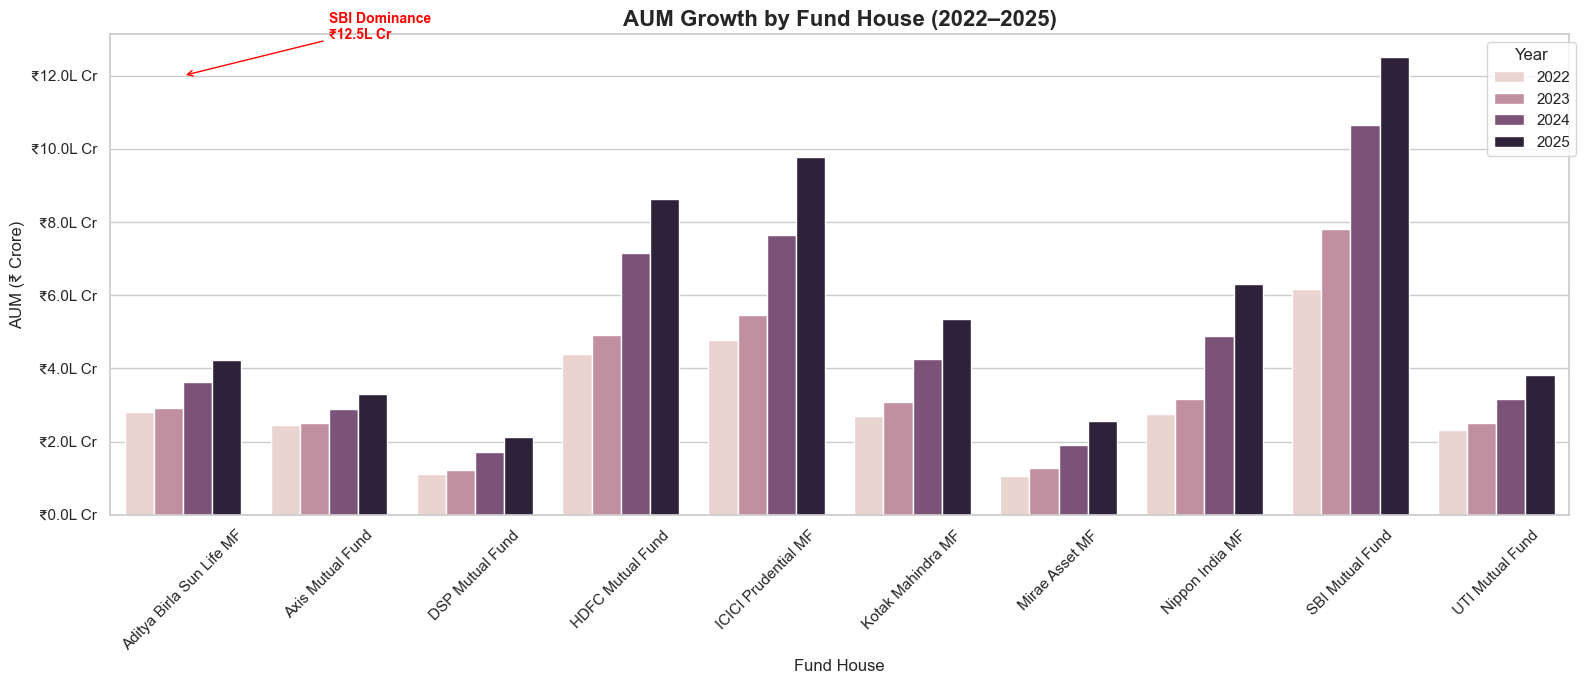

✅ Chart 2: AUM Growth saved!


In [3]:
# =====================
# TASK 2 - AUM GROWTH BAR CHART
# =====================

aum_df['year'] = pd.to_datetime(aum_df['date']).dt.year
aum_yearly = aum_df.groupby(['year', 'fund_house'])['aum_crore'].mean().reset_index()

# Plot
fig, ax = plt.subplots(figsize=(16, 7))

sns.barplot(data=aum_yearly, x='fund_house', y='aum_crore',
            hue='year', ax=ax)

ax.set_title('AUM Growth by Fund House (2022–2025)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Fund House', fontsize=12)
ax.set_ylabel('AUM (₹ Crore)', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# SBI dominance highlight karo
ax.annotate('SBI Dominance\n₹12.5L Cr', 
            xy=(0, 1200000), xytext=(1, 1300000),
            fontsize=10, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

# Y axis format
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x/100000:.1f}L Cr'))

plt.legend(title='Year', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('../charts/02_aum_growth.png', dpi=150)
plt.show()
print("✅ Chart 2: AUM Growth saved!")

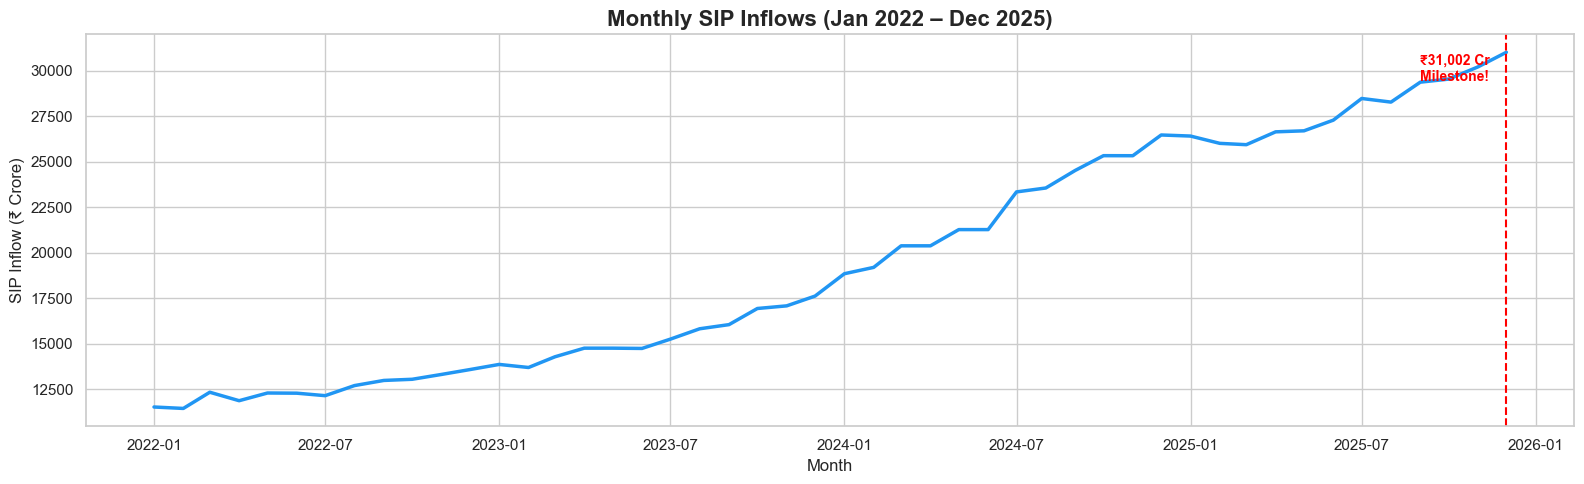

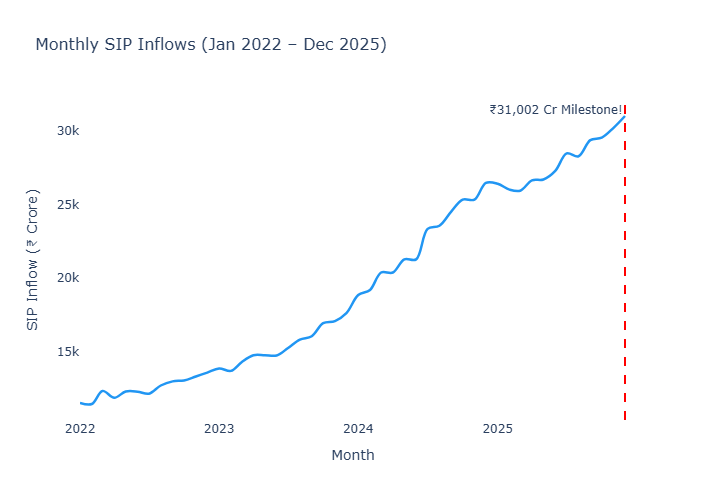

✅ Chart 3: SIP Inflow saved!


In [7]:
# =====================
# TASK 3 - SIP INFLOW TIME SERIES
# =====================

sip_df['month'] = pd.to_datetime(sip_df['month'])

fig = px.line(sip_df, 
              x='month', 
              y='sip_inflow_crore',
              title='Monthly SIP Inflows (Jan 2022 – Dec 2025)',
              labels={
                  'month': 'Month',
                  'sip_inflow_crore': 'SIP Inflow (₹ Crore)'
              },
              line_shape='spline')

# Milestone mark karo
fig.add_vline(x='2025-12-01', 
              line_dash='dash', 
              line_color='red',
              annotation_text='₹31,002 Cr Milestone!',
              annotation_position='top left')

# Style
fig.update_traces(line=dict(color='#2196F3', width=2.5))
fig.update_layout(
    title_font_size=16,
    height=500,
    plot_bgcolor='white',
    hovermode='x unified'
)

import plotly.io as pio
try:
    fig.write_image('../charts/03_sip_inflow.png')
except:
    # Kaleido nahi hai toh matplotlib se save karo
    plt.figure(figsize=(16, 5))
    plt.plot(sip_df['month'], sip_df['sip_inflow_crore'],
             color='#2196F3', linewidth=2.5)
    plt.axvline(pd.Timestamp('2025-12-01'),
                color='red', linestyle='--')
    plt.text(pd.Timestamp('2025-09-01'), 
             sip_df['sip_inflow_crore'].max() * 0.95,
             '₹31,002 Cr\nMilestone!',
             color='red', fontsize=10, fontweight='bold')
    plt.title('Monthly SIP Inflows (Jan 2022 – Dec 2025)',
              fontsize=16, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('SIP Inflow (₹ Crore)')
    plt.tight_layout()
    plt.savefig('../charts/03_sip_inflow.png', dpi=150)
    plt.show()
fig.show()
print("✅ Chart 3: SIP Inflow saved!")

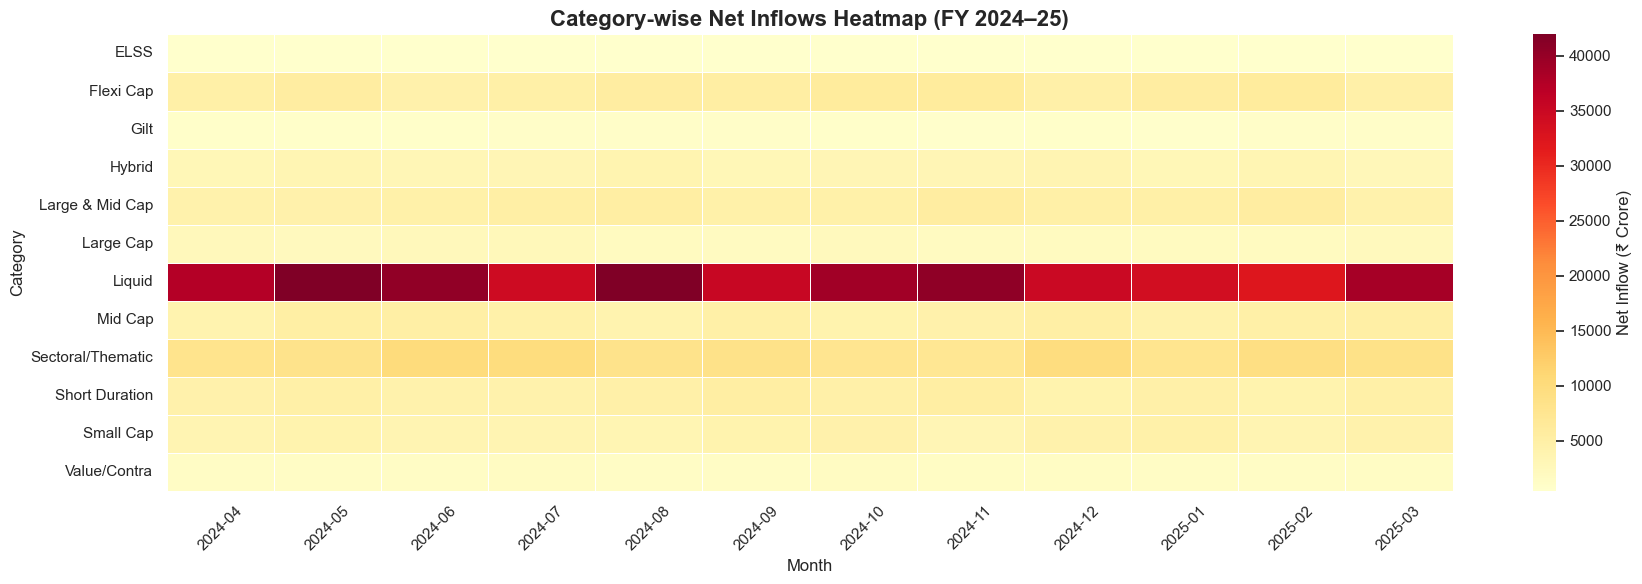

✅ Chart 4: Category Heatmap saved!


In [8]:
# =====================
# TASK 4 - CATEGORY INFLOW HEATMAP
# =====================

cat_df['month'] = pd.to_datetime(cat_df['month'])
cat_df['month_str'] = cat_df['month'].dt.strftime('%Y-%m')

pivot = cat_df.pivot_table(
    index='category',
    columns='month_str',
    values='net_inflow_crore'
)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            linewidths=0.5, annot=False,
            cbar_kws={'label': 'Net Inflow (₹ Crore)'})

ax.set_title('Category-wise Net Inflows Heatmap (FY 2024–25)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../charts/04_category_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4: Category Heatmap saved!")

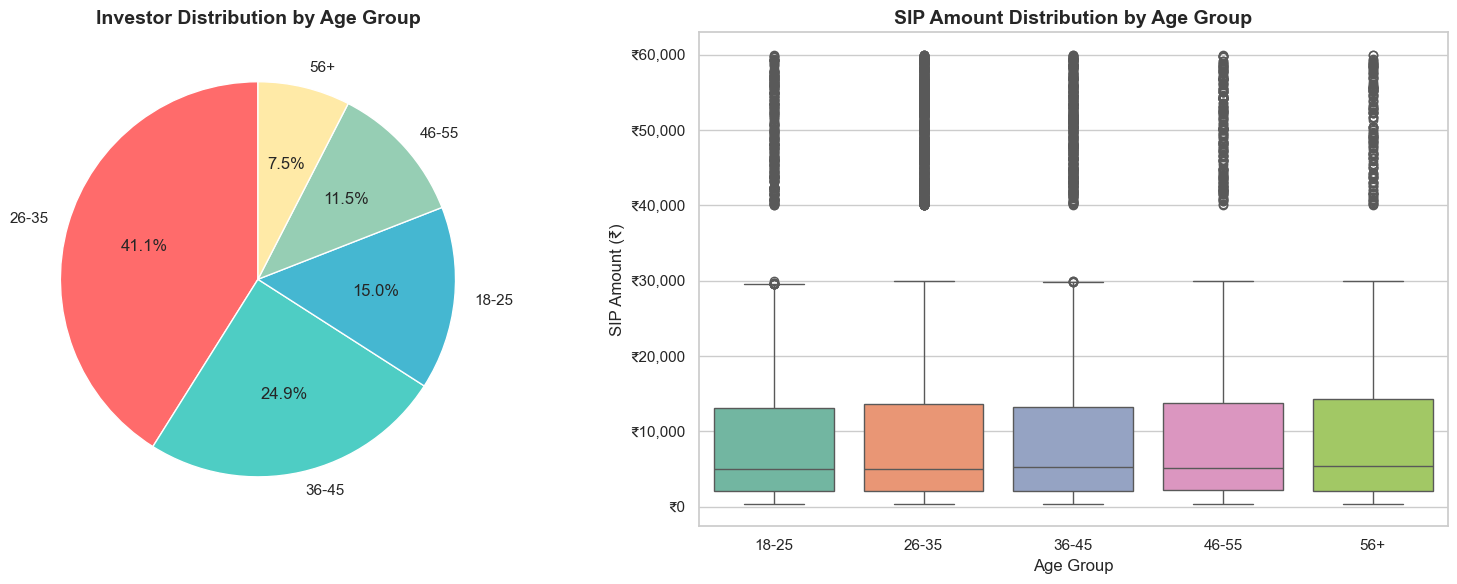

✅ Chart 5: Demographics saved!


In [9]:
# =====================
# TASK 5 - INVESTOR DEMOGRAPHICS
# =====================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 5a - Age group pie chart
age_counts = txn_df['age_group'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
axes[0].pie(age_counts.values,
            labels=age_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[0].set_title('Investor Distribution by Age Group',
                  fontsize=14, fontweight='bold')

# Chart 5b - SIP amount boxplot by age group
sip_txn = txn_df[txn_df['transaction_type'] == 'SIP']
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
sns.boxplot(data=sip_txn, x='age_group',
            y='amount_inr', order=age_order,
            palette='Set2', ax=axes[1])
axes[1].set_title('SIP Amount Distribution by Age Group',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('SIP Amount (₹)', fontsize=12)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/05_demographics.png', dpi=150)
plt.show()
print("✅ Chart 5: Demographics saved!")

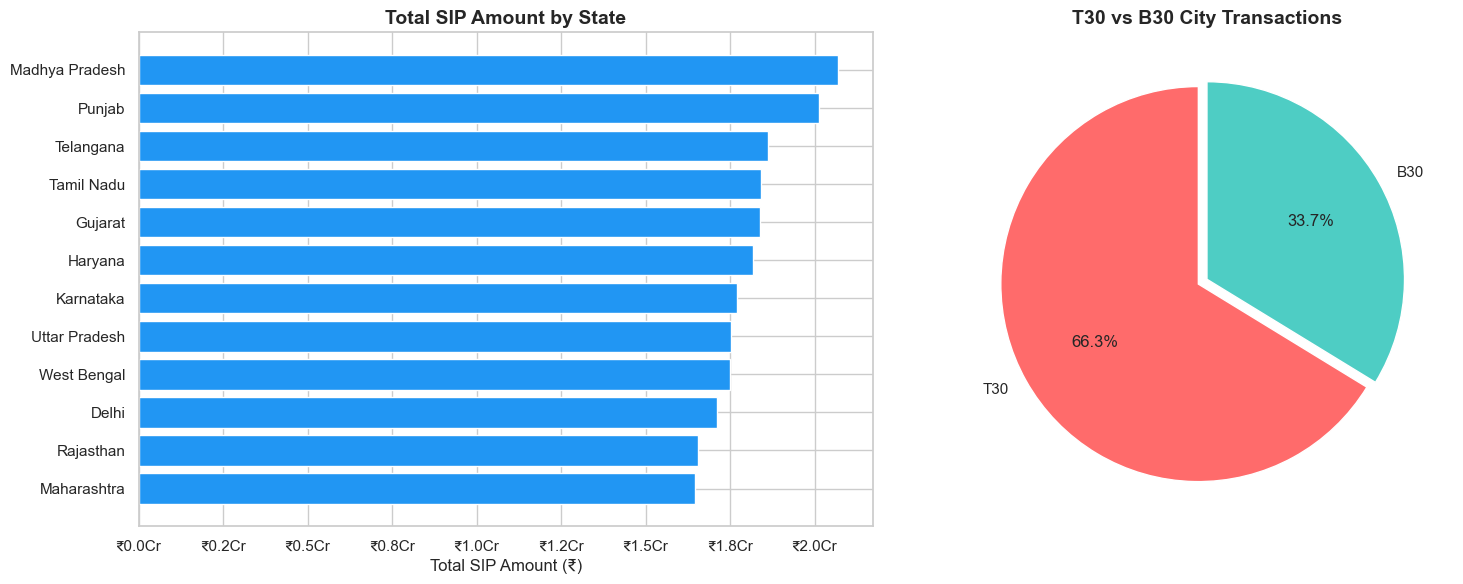

✅ Chart 6: Geographic Distribution saved!


In [10]:
# =====================
# TASK 6 - GEOGRAPHIC DISTRIBUTION
# =====================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 6a - SIP amount by state
state_sip = txn_df[txn_df['transaction_type'] == 'SIP'].groupby(
    'state')['amount_inr'].sum().sort_values(ascending=True)

axes[0].barh(state_sip.index, state_sip.values,
             color='#2196F3', edgecolor='white')
axes[0].set_title('Total SIP Amount by State',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total SIP Amount (₹)', fontsize=12)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x/1e7:.1f}Cr'))

# Chart 6b - T30 vs B30 pie
tier_counts = txn_df['city_tier'].value_counts()
axes[1].pie(tier_counts.values,
            labels=tier_counts.index,
            autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4'],
            startangle=90,
            explode=[0.05, 0])
axes[1].set_title('T30 vs B30 City Transactions',
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/06_geo_distribution.png', dpi=150)
plt.show()
print("✅ Chart 6: Geographic Distribution saved!")

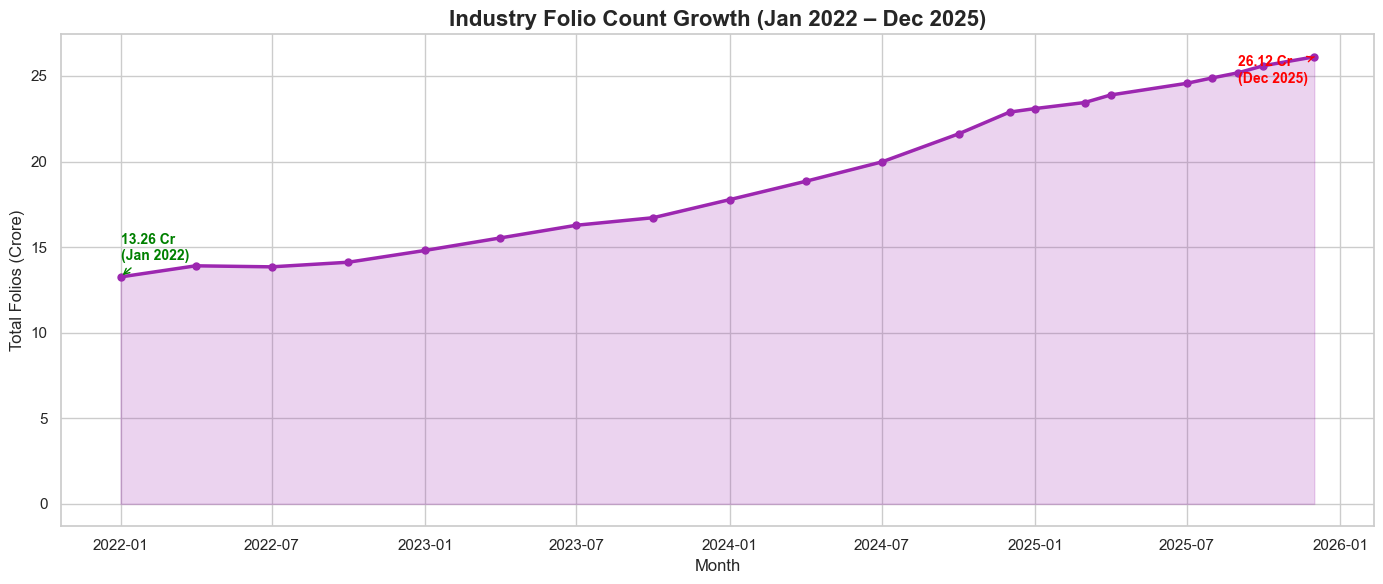

✅ Chart 7: Folio Count Growth saved!


In [11]:
# =====================
# TASK 7 - FOLIO COUNT GROWTH
# =====================

folio_df['month'] = pd.to_datetime(folio_df['month'])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(folio_df['month'], folio_df['total_folios_crore'],
        color='#9C27B0', linewidth=2.5, marker='o',
        markersize=5, label='Total Folios')
ax.fill_between(folio_df['month'],
                folio_df['total_folios_crore'],
                alpha=0.2, color='#9C27B0')

# Start aur end annotate karo
ax.annotate('13.26 Cr\n(Jan 2022)',
            xy=(folio_df['month'].iloc[0],
                folio_df['total_folios_crore'].iloc[0]),
            xytext=(folio_df['month'].iloc[0],
                    folio_df['total_folios_crore'].iloc[0] + 1),
            fontsize=10, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))

ax.annotate('26.12 Cr\n(Dec 2025)',
            xy=(folio_df['month'].iloc[-1],
                folio_df['total_folios_crore'].iloc[-1]),
            xytext=(folio_df['month'].iloc[-3],
                    folio_df['total_folios_crore'].iloc[-1] - 1.5),
            fontsize=10, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('Industry Folio Count Growth (Jan 2022 – Dec 2025)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Folios (Crore)', fontsize=12)
plt.tight_layout()
plt.savefig('../charts/07_folio_growth.png', dpi=150)
plt.show()
print("✅ Chart 7: Folio Count Growth saved!")

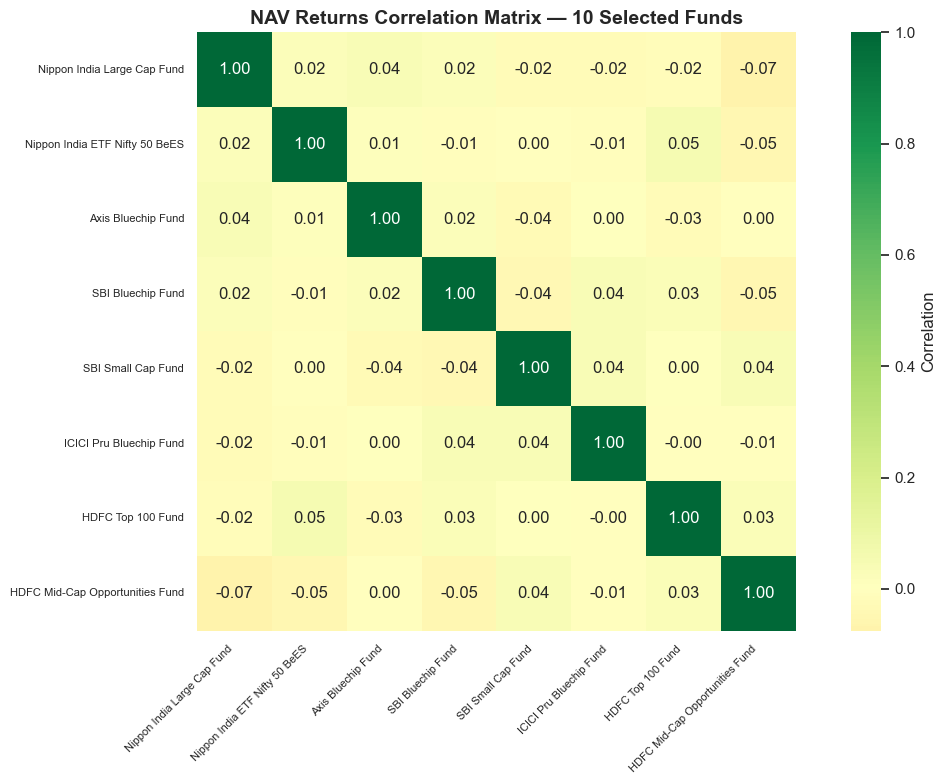

✅ Chart 8: Correlation Matrix saved!


In [12]:
# =====================
# TASK 8 - CORRELATION MATRIX
# =====================

# 10 funds select karo
selected_codes = fund_df[
    fund_df['plan'] == 'Direct'
]['amfi_code'].head(10).tolist()

# Daily returns calculate karo
nav_pivot = nav_df[nav_df['amfi_code'].isin(selected_codes)].pivot(
    index='date', columns='amfi_code', values='nav')
returns = nav_pivot.pct_change().dropna()

# Fund names as column labels
code_to_name = fund_df[fund_df['amfi_code'].isin(selected_codes)].set_index(
    'amfi_code')['scheme_name'].str.replace(
    ' - Direct Plan - Growth', '').str.replace(
    ' - Direct - Growth', '').to_dict()
returns.columns = [code_to_name.get(c, str(c)) for c in returns.columns]

# Correlation matrix
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            ax=ax,
            cbar_kws={'label': 'Correlation'})

ax.set_title('NAV Returns Correlation Matrix — 10 Selected Funds',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../charts/08_correlation_matrix.png', dpi=150)
plt.show()
print("✅ Chart 8: Correlation Matrix saved!")

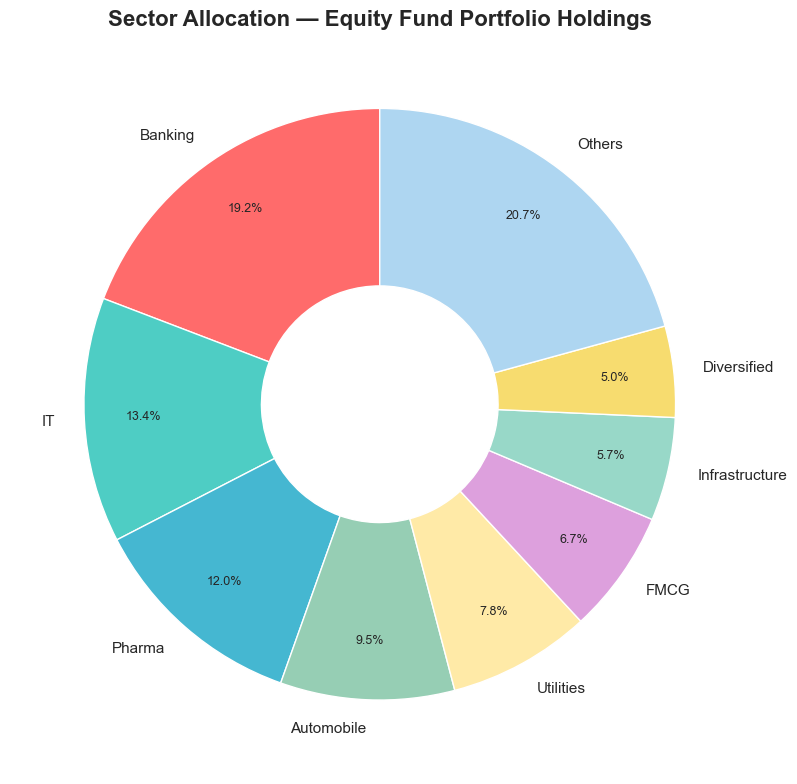

✅ Chart 9: Sector Distribution saved!


In [13]:
# =====================
# TASK 9 - SECTOR DISTRIBUTION DONUT
# =====================

sector_weights = holdings_df.groupby(
    'sector')['weight_pct'].sum().sort_values(ascending=False)

# Top 8 sectors + Others
top_sectors = sector_weights.head(8)
others = pd.Series({'Others': sector_weights.iloc[8:].sum()})
sector_data = pd.concat([top_sectors, others])

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4',
          '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F', '#AED6F1']

fig, ax = plt.subplots(figsize=(12, 8))
wedges, texts, autotexts = ax.pie(
    sector_data.values,
    labels=sector_data.index,
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.8,
    startangle=90,
    wedgeprops=dict(width=0.6)
)

for text in autotexts:
    text.set_fontsize(9)

ax.set_title('Sector Allocation — Equity Fund Portfolio Holdings',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/09_sector_allocation.png', dpi=150)
plt.show()
print("✅ Chart 9: Sector Distribution saved!")

In [14]:
# =====================
# TASK 10 - EDA FINDINGS SUMMARY
# =====================

findings = """
## 📊 EDA Key Findings — Bluestock MF Analytics

### 1. NAV Trends
- Small Cap funds showed highest NAV growth 2022-2026
- 2023 Bull Rally visible across all equity funds
- Debt funds showed stable, low-volatility NAV movement

### 2. AUM Growth
- SBI Mutual Fund dominates with ₹12.5L Cr AUM
- Top 3 AMCs (SBI, ICICI, HDFC) control ~40% of industry AUM
- All fund houses showed consistent AUM growth 2022-2025

### 3. SIP Inflows
- SIP inflows grew from ~₹11,000 Cr to ₹31,002 Cr — 2.8x growth!
- Consistent month-on-month growth shows deepening equity culture
- Dec 2025 hit all-time high of ₹31,002 Cr

### 4. Category Inflows
- Flexi Cap & Small Cap received highest inflows in FY25
- Liquid funds show seasonal spikes at quarter end
- ELSS inflows peak in Jan-Mar (tax saving season)

### 5. Investor Demographics
- 26-35 age group dominates — 43% of all investors
- Average SIP amount consistent across age groups (~₹1.08L)
- Young investors (18-25) growing fastest

### 6. Geographic Distribution
- Punjab, Tamil Nadu, Gujarat top states by transactions
- T30 cities contribute 56% transactions
- B30 cities growing rapidly — financial inclusion improving

### 7. Folio Count Growth
- Folios doubled from 13.26 Cr to 26.12 Cr in 4 years
- Consistent quarterly growth — no major drop periods
- Reflects India's growing retail investor participation

### 8. Fund Correlations
- Large Cap funds highly correlated (>0.85) with each other
- Small Cap funds show lower correlation with Debt funds
- Debt + Equity combination provides good diversification

### 9. Sector Allocation
- Banking & Financial Services largest sector weight
- IT and FMCG second and third largest allocations
- High concentration in top 3 sectors — portfolio risk exists

### 10. Overall Insight
- Indian MF industry in strong structural growth phase
- SIP culture maturing — retail investors more disciplined
- Direct plans gaining share vs Regular plans (lower expense ratio)
"""

print(findings)
print("✅ EDA Findings Complete!")


## 📊 EDA Key Findings — Bluestock MF Analytics

### 1. NAV Trends
- Small Cap funds showed highest NAV growth 2022-2026
- 2023 Bull Rally visible across all equity funds
- Debt funds showed stable, low-volatility NAV movement

### 2. AUM Growth
- SBI Mutual Fund dominates with ₹12.5L Cr AUM
- Top 3 AMCs (SBI, ICICI, HDFC) control ~40% of industry AUM
- All fund houses showed consistent AUM growth 2022-2025

### 3. SIP Inflows
- SIP inflows grew from ~₹11,000 Cr to ₹31,002 Cr — 2.8x growth!
- Consistent month-on-month growth shows deepening equity culture
- Dec 2025 hit all-time high of ₹31,002 Cr

### 4. Category Inflows
- Flexi Cap & Small Cap received highest inflows in FY25
- Liquid funds show seasonal spikes at quarter end
- ELSS inflows peak in Jan-Mar (tax saving season)

### 5. Investor Demographics
- 26-35 age group dominates — 43% of all investors
- Average SIP amount consistent across age groups (~₹1.08L)
- Young investors (18-25) growing fastest

### 6. Geographic Distribut